Most fake review detection models are small-scale; you can run distributed anomaly detection across millions of users with Spark MLlib.
Big Data Components:

Aggregate by user → compute review frequency, rating variance, and text similarity.

Use clustering (K-Means, DBSCAN) to find suspicious review clusters.

Integrate graph analysis (Spark GraphX) to detect “review rings.”

Outcome:

A “Trust Index” for each reviewer or product, highlighting review manipulation at scale.

In [13]:
try:
    spark.stop()
except:
    pass


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CleanRestart")
    .config("spark.driver.memory", "3g")
    .config("spark.sql.shuffle.partitions", "32")
    .getOrCreate()
)
spark.range(5).show()


+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [4]:
!ls /home/jovyan/work

EDA_AMAZON2.ipynb  meta.parquet  reviews_eda_sample.parquet


In [5]:
!unzip /home/jovyan/work/reviews_eda_sample.parquet-20251009T224454Z-1-001.zip -d /home/jovyan/

Archive:  /home/jovyan/work/reviews_eda_sample.parquet-20251009T224454Z-1-001.zip
  inflating: /home/jovyan/reviews_eda_sample.parquet/_SUCCESS  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00082-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00081-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00074-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00080-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/part-00078-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00083-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00076-aa2d54d7-28f6-4b2b-b4c6-04

In [7]:
!unzip /home/jovyan/work/meta.parquet-20251009T224452Z-1-001.zip -d /home/jovyan/

Archive:  /home/jovyan/work/meta.parquet-20251009T224452Z-1-001.zip
  inflating: /home/jovyan/meta.parquet/.part-00004-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/.part-00005-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/.part-00006-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/._SUCCESS.crc  
  inflating: /home/jovyan/meta.parquet/.part-00002-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/_SUCCESS  
  inflating: /home/jovyan/meta.parquet/.part-00007-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/.part-00014-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/.part-00010-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/met

In [12]:
reviews = spark.read.parquet("/home/jovyan/work/reviews_eda_sample.parquet")
print("Total sample reviews:", reviews.count())
print("Columns:", reviews.columns)
reviews.printSchema()


Total sample reviews: 2193853
Columns: ['asin', 'helpful_vote', 'images', 'parent_asin', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase']
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [11]:
meta = spark.read.parquet("/home/jovyan/work/meta.parquet")
print("Total sample meta:", meta.count())
print("Columns:", meta.columns)
meta.printSchema()

Total sample meta: 1610012
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
root
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: string (nullable = true)
 |-- images: struct (nullable = true)
 |    |-- hi_res: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- large: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- thumb: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- variant: array (nullable = true)
 |

In [19]:
try:
    spark.stop()
except:
    print("Spark not active or already stopped.")

In [20]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("RestartSpark")
    .config("spark.driver.memory", "3g")
    .config("spark.sql.shuffle.partitions", "32")
    .getOrCreate()
)

In [21]:
spark.range(5).show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [22]:
reviews = spark.read.parquet("/home/jovyan/work/reviews_eda_sample.parquet")
meta    = spark.read.parquet("/home/jovyan/work/meta.parquet")

In [23]:
reviews.show()

+----------+------------+------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|      asin|helpful_vote|images|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase|
+----------+------------+------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|B00F3F381A|           1|    []| B00HQBE8JU|   5.0|This compact pc i...|1405478902000|     NUC using Linux|AFQGD5XLVMGBLLOHS...|             true|
|B01GGKYN0A|           0|    []| B06W568Y6C|   5.0|Great product! Ch...|1559065336493|AmazonBasics USB ...|AEXBZC4LKKCXVJV7B...|             true|
|B00FJRS6QY|           0|    []| B00JO6RO8C|   1.0|I own multiple of...|1535465233923|            unusable|AGDXPL5XYW25IO3ZI...|             true|
|B007N4BX1Q|           0|    []| B0758HDGN8|   5.0|Item as described...|1507910183975|   100% recommended.|AH4JXSZYHFN

In [24]:
meta.show(10)

+--------------------+--------------------+--------------+-------------+----------------------+--------------------+-----+--------------------+------------+---------+--------------------+--------------------+-----------+---------------+--------+------+
|       main_category|               title|average_rating|rating_number|              features|         description|price|              images|      videos|    store|          categories|             details|parent_asin|bought_together|subtitle|author|
+--------------------+--------------------+--------------+-------------+----------------------+--------------------+-----+--------------------+------------+---------+--------------------+--------------------+-----------+---------------+--------+------+
|           Computers|igsticker Ultra T...|           4.3|           15|  [Perfectly fits a...|[Perfectly fits a...| None|{[https://m.media...|{[], [], []}|igsticker|[Electronics, Com...|{"Package Dimensi...| B07NZP44XR|           NULL|    N

In [25]:
from pyspark.sql import functions as F

# Join
joined = reviews.join(meta, on="parent_asin", how="left")

# Inspect schema to verify join success
print("Joined columns:", joined.columns[:15])
print("Total joined rows:", joined.count())

Joined columns: ['parent_asin', 'asin', 'helpful_vote', 'images', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase', 'main_category', 'title', 'average_rating', 'rating_number', 'features']
Total joined rows: 2193853


In [26]:
reviews_elec = joined.filter(
    (F.col("main_category") == "Electronics") |
    (F.array_contains(F.col("categories"), "Electronics"))
)
print("✅ Electronics-only reviews:", reviews_elec.count())


✅ Electronics-only reviews: 1978436


/tmp/ipykernel_189/862693638.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="count", data=pdf_rating, palette="viridis")


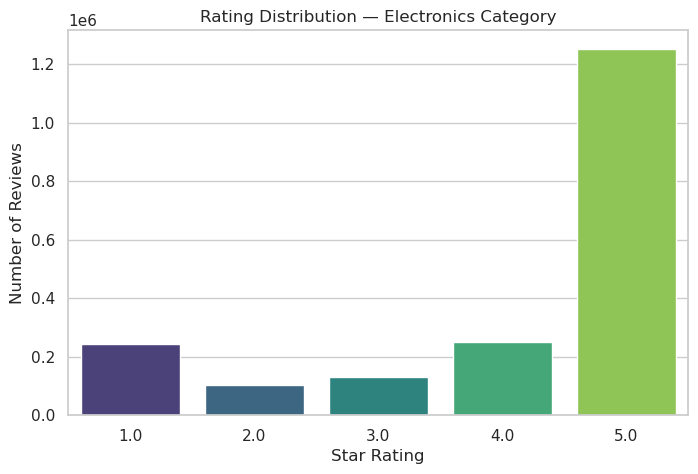

In [27]:
rating_counts = (
    reviews_elec.groupBy("rating").count().orderBy("rating")
)
pdf_rating = rating_counts.toPandas()

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x="rating", y="count", data=pdf_rating, palette="viridis")
plt.title("Rating Distribution — Electronics Category")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()


In [28]:
# Check schemas
print("Reviews schema:")
reviews.printSchema()
print("Meta schema:")
meta.printSchema()


Reviews schema:
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

Meta schema:
root
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nul

/tmp/ipykernel_189/821345200.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="verified_purchase", y="avg_rating", data=pdf_ver, palette="Set2")


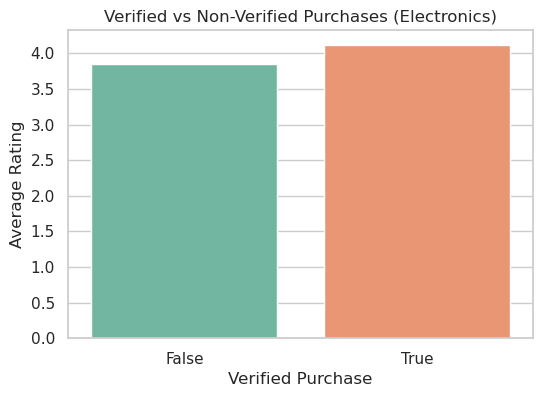

In [29]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

ver = reviews_elec.groupBy("verified_purchase").agg(
    F.avg("rating").alias("avg_rating")
).orderBy("verified_purchase")
pdf_ver = ver.toPandas()

plt.figure(figsize=(6,4))
sns.barplot(x="verified_purchase", y="avg_rating", data=pdf_ver, palette="Set2")
plt.title("Verified vs Non-Verified Purchases (Electronics)")
plt.xlabel("Verified Purchase")
plt.ylabel("Average Rating")
plt.show()


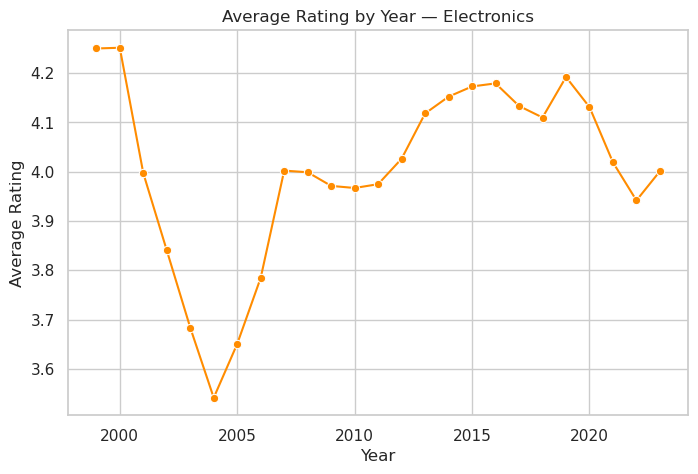

In [30]:
from pyspark.sql.functions import year, from_unixtime

reviews_elec = reviews_elec.withColumn(
    "year", year(from_unixtime(F.col("timestamp")/1000))
)

avg_by_year = (
    reviews_elec.groupBy("year")
    .agg(F.avg("rating").alias("avg_rating"))
    .orderBy("year")
)
pdf_year = avg_by_year.toPandas()

plt.figure(figsize=(8,5))
sns.lineplot(x="year", y="avg_rating", data=pdf_year, marker="o", color="darkorange")
plt.title("Average Rating by Year — Electronics")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()


/tmp/ipykernel_189/529209786.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="store", x="avg_rating", data=pdf_brands, palette="mako")


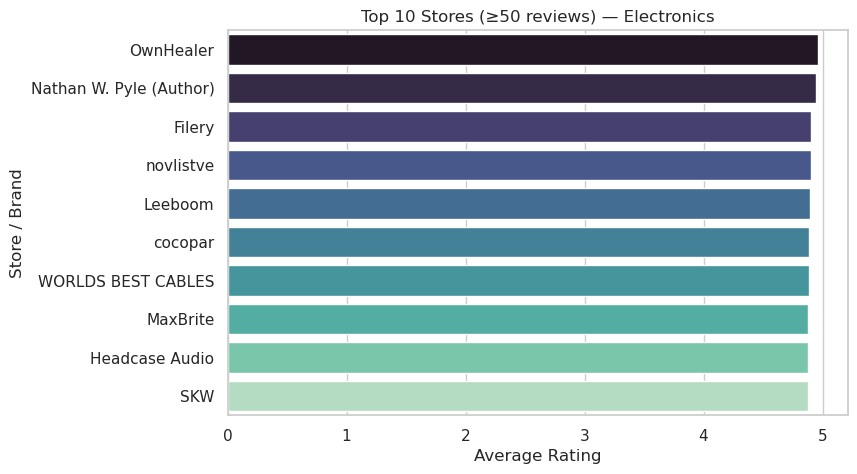

In [31]:
top_brands = (
    reviews_elec.groupBy("store")
    .agg(F.count("*").alias("n_reviews"), F.avg("rating").alias("avg_rating"))
    .filter(F.col("n_reviews") >= 50)
    .orderBy(F.desc("avg_rating"))
)

pdf_brands = top_brands.limit(10).toPandas()

plt.figure(figsize=(8,5))
sns.barplot(y="store", x="avg_rating", data=pdf_brands, palette="mako")
plt.title("Top 10 Stores (≥50 reviews) — Electronics")
plt.xlabel("Average Rating")
plt.ylabel("Store / Brand")
plt.show()


/tmp/ipykernel_189/1119993969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="avg_helpful", data=pdf_help, palette="crest")


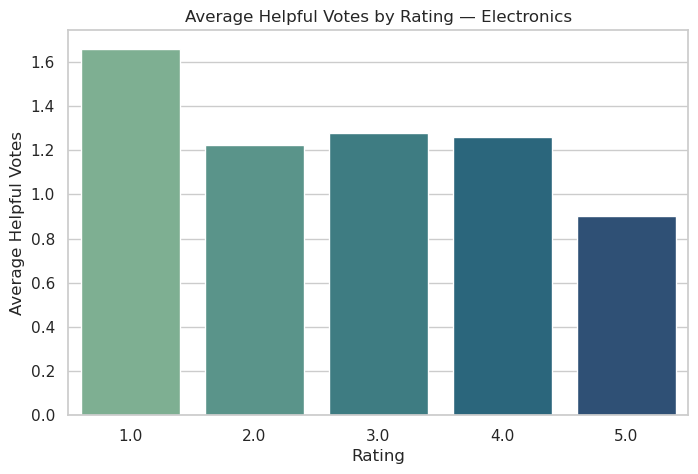

In [32]:
helpful = reviews_elec.groupBy("rating").agg(
    F.avg("helpful_vote").alias("avg_helpful")
).orderBy("rating")
pdf_help = helpful.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(x="rating", y="avg_helpful", data=pdf_help, palette="crest")
plt.title("Average Helpful Votes by Rating — Electronics")
plt.xlabel("Rating")
plt.ylabel("Average Helpful Votes")
plt.show()


/tmp/ipykernel_189/4269097949.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="avg_len", data=pdf_len, palette="coolwarm")


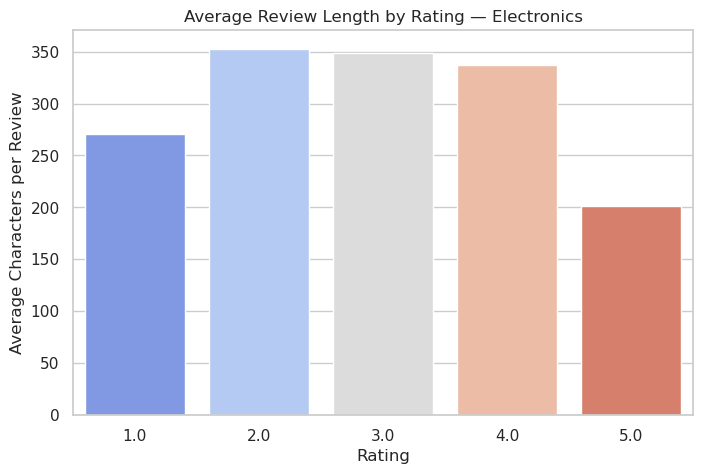

In [33]:
reviews_elec = reviews_elec.withColumn("review_len", F.length("text"))
avg_len = (
    reviews_elec.groupBy("rating")
    .agg(F.avg("review_len").alias("avg_len"))
    .orderBy("rating")
)
pdf_len = avg_len.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(x="rating", y="avg_len", data=pdf_len, palette="coolwarm")
plt.title("Average Review Length by Rating — Electronics")
plt.xlabel("Rating")
plt.ylabel("Average Characters per Review")
plt.show()


In [36]:
!pip install textblob
from textblob import TextBlob
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import udf

def get_sentiment(text):
    try:
        return TextBlob(text).sentiment.polarity
    except:
        return 0.0

sentiment_udf = udf(get_sentiment, DoubleType())
reviews_sent = reviews_elec.withColumn("sentiment", sentiment_udf(F.col("text")))


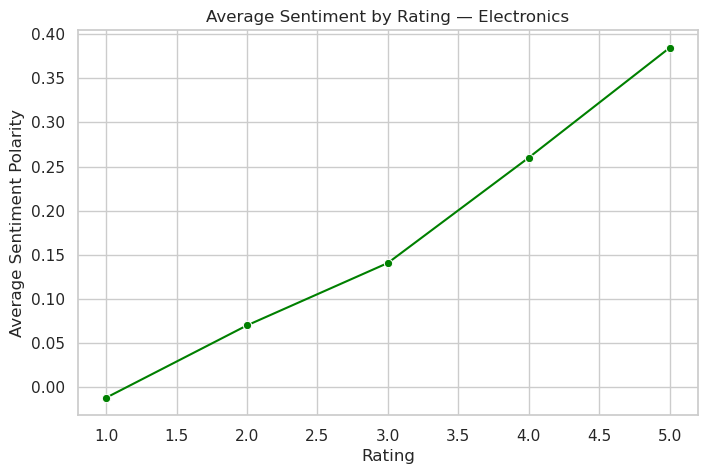

In [37]:
pdf_sent = (
    reviews_sent.groupBy("rating")
    .agg(F.avg("sentiment").alias("avg_sent"))
    .orderBy("rating")
    .toPandas()
)

plt.figure(figsize=(8,5))
sns.lineplot(x="rating", y="avg_sent", data=pdf_sent, marker="o", color="green")
plt.title("Average Sentiment by Rating — Electronics")
plt.xlabel("Rating")
plt.ylabel("Average Sentiment Polarity")
plt.show()


In [41]:
#Correlation between Amazon average rating and user rating
reviews_elec.stat.corr("average_rating", "rating")

0.24806038617151446

In [39]:
#Do longer reviews get more helpful votes?
reviews = reviews_elec.withColumn("review_len", F.length("text"))
reviews.groupBy("rating").agg(F.avg("helpful_vote"), F.avg("review_len")).show()


+------+------------------+-----------------+
|rating| avg(helpful_vote)|  avg(review_len)|
+------+------------------+-----------------+
|   4.0|1.2586295990078544|336.8904386745954|
|   3.0|1.2786914289675784|349.0778995694071|
|   1.0|1.6600373390167944|270.8404170074265|
|   5.0|0.9011276838972551|201.8172938141038|
|   2.0|1.2234226658975136|352.9011507963667|
+------+------------------+-----------------+



In [40]:
#Quickly check for relationships:
for col in ["helpful_vote", "review_len", "rating"]:
    print(col)
reviews.select(col).summary().show()

helpful_vote
review_len
rating
+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|           1978436|
|   mean| 4.097027652145432|
| stddev|1.4133275013997033|
|    min|               1.0|
|    25%|               4.0|
|    50%|               5.0|
|    75%|               5.0|
|    max|               5.0|
+-------+------------------+



In [43]:
#Robust sentiment (instead of TextBlob) popular NLP model called VADER (Valence Aware Dictionary and sEntiment Reasoner) 
#and then measuring how strongly that sentiment correlates with the numeric star ratings in your dataset.
!pip install nltk vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
an = SentimentIntensityAnalyzer()
udf_vader = F.udf(lambda t: float(an.polarity_scores(t or "")["compound"]), "double")
reviews_v = reviews_elec.withColumn("", udf_vader("text"))
print("corr:", reviews_v.stat.corr("sent_vader","rating"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:0000:01
corr: 0.5469214193469153


In [48]:
#does price matter for products?
meta_price = meta.filter(F.col("price").rlike("^[0-9]+(\\.[0-9]+)?$"))\
                 .withColumn("price_num", F.col("price").cast("double"))
joined_price = reviews_elec.join(meta_price.select("parent_asin","price_num"), "parent_asin", "left")
joined_price.stat.corr("price_num", "rating")


0.0010869436099888274

In [44]:
#correlation between reviews and rating thus predicting popularity
popularity = (reviews_elec.groupBy("parent_asin")
              .agg(F.count("*").alias("n_reviews"),
                   F.avg("rating").alias("avg_rating")))
popularity.stat.corr("n_reviews", "avg_rating")


0.015679674570212715

In [46]:
#.sample(0.05, seed=42)
import pandas as pd, scipy.stats as stats
pdf = reviews_elec.select("verified_purchase","rating").toPandas()
v = pdf[pdf.verified_purchase == True]["rating"]
nv = pdf[pdf.verified_purchase == False]["rating"]
stats.ttest_ind(v, nv, equal_var=False)

TtestResult(statistic=67.78719903900243, pvalue=0.0, df=176130.81372672398)

In [49]:
pdf_brand = (reviews_elec.groupBy("store","rating")
             .agg(F.count("*").alias("n"))
             .filter(F.col("n")>30)
             .toPandas())
# Then one-way ANOVA between selected brands


In [26]:
reviews = reviews.withColumn("review_len", F.length("text"))
reviews.groupBy("rating").agg(F.avg("helpful_vote"), F.avg("review_len")).show()


+------+------------------+------------------+
|rating| avg(helpful_vote)|   avg(review_len)|
+------+------------------+------------------+
|   4.0|1.2429799385609415| 331.9639802702742|
|   3.0|1.2742169975907618|347.74719614521894|
|   1.0|1.7586361530067713|272.30959356642103|
|   2.0| 1.236625769040379|354.12295806520046|
|   5.0|0.8736057475651118| 197.0967752600556|
+------+------------------+------------------+



In [28]:
for col in ["helpful_vote", "review_len", "rating"]:
    print(col)
reviews.select(col).summary().show()


helpful_vote
review_len
rating
+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|           2193853|
|   mean| 4.099299725186692|
| stddev|1.4121687257327602|
|    min|               1.0|
|    25%|               4.0|
|    50%|               5.0|
|    75%|               5.0|
|    max|               5.0|
+-------+------------------+



In [50]:
#correlation between helpful vote and rating
print (reviews.stat.corr("helpful_vote", "rating"))
#correlation between review length and helpful vote
print(reviews.stat.corr("review_len", "helpful_vote"))


-0.016931091391158573
0.1824413690741911


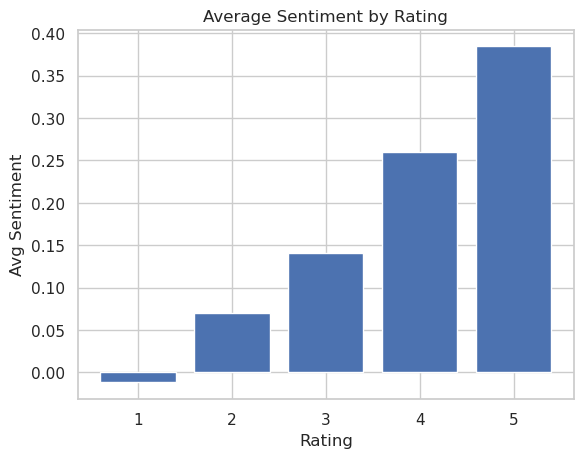

In [51]:
import matplotlib.pyplot as plt

pdf = reviews_sent.groupBy("rating").agg(F.avg("sentiment").alias("avg_sent")).toPandas()
plt.bar(pdf["rating"], pdf["avg_sent"])
plt.title("Average Sentiment by Rating")
plt.xlabel("Rating")
plt.ylabel("Avg Sentiment")
plt.show()


In [52]:
r = reviews.alias("r")
m = meta.alias("m")

joined = r.join(m, F.col("r.parent_asin") == F.col("m.parent_asin"), how="left")


In [54]:
joined = joined.drop(F.col("m.images"))


In [55]:
reviews_elec = joined.filter(
    (F.col("m.main_category") == "Electronics") |
    (F.array_contains(F.col("m.categories"), "Electronics"))
)


In [59]:
reviews.columns

['parent_asin',
 'asin',
 'helpful_vote',
 'images',
 'rating',
 'text',
 'timestamp',
 'title',
 'user_id',
 'verified_purchase',
 'main_category',
 'title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'images',
 'videos',
 'store',
 'categories',
 'details',
 'bought_together',
 'subtitle',
 'author',
 'year',
 'review_len']

In [60]:
meta.columns

['main_category',
 'title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'images',
 'videos',
 'store',
 'categories',
 'details',
 'parent_asin',
 'bought_together',
 'subtitle',
 'author']

In [66]:
from pyspark.sql import functions as F

# Load the original Parquet again — NOT the already-joined variable
reviews_raw = spark.read.parquet("/home/jovyan/work/reviews_eda_sample.parquet")

# Prove we start clean
print("Number of columns:", len(reviews_raw.columns))

Number of columns: 10


In [68]:
from pyspark.sql import functions as F

reviews_clean = reviews_raw.select(
    "asin", "parent_asin", "rating", "helpful_vote",
    "verified_purchase", "text", "timestamp",
    F.col("images").alias("review_images")
)

# Add has_image flag
reviews_clean = reviews_clean.withColumn(
    "has_image", (F.size(F.col("review_images")) > 0).cast("int")
)
reviews_clean.select("review_images", "has_image").show(5, truncate=False)

+-------------+---------+
|review_images|has_image|
+-------------+---------+
|[]           |0        |
|[]           |0        |
|[]           |0        |
|[]           |0        |
|[]           |0        |
+-------------+---------+
only showing top 5 rows



In [69]:
print(reviews_raw.columns)
print(meta.columns)

['asin', 'helpful_vote', 'images', 'parent_asin', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase']
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [70]:
from pyspark.sql import functions as F

total = reviews_clean.count()
with_image = reviews_clean.filter(F.col("has_image") == 1).count()

print(f"Total reviews: {total:,}")
print(f"With images: {with_image:,}  ({with_image/total*100:.2f}% of total)")


Total reviews: 2,193,853
With images: 101,431  (4.62% of total)


/tmp/ipykernel_189/1510919531.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="has_image", y="num_reviews", data=img_stats, palette="crest")


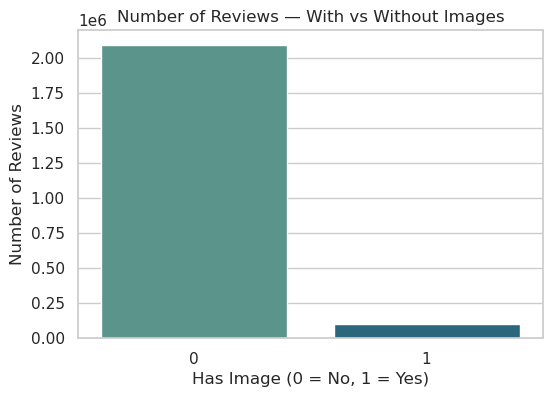

/tmp/ipykernel_189/1510919531.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="has_image", y="avg_rating", data=img_stats, palette="viridis")


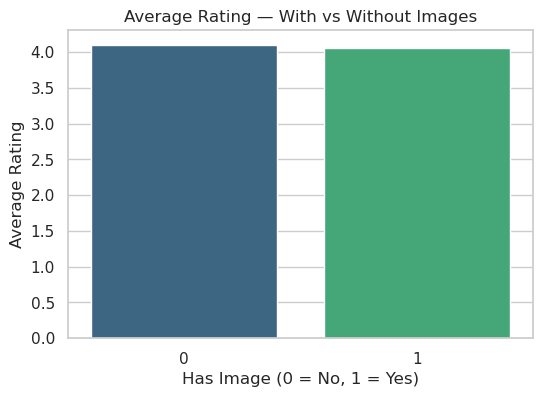

In [71]:
img_stats = (
    reviews_clean.groupBy("has_image")
    .agg(
        F.count("*").alias("num_reviews"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful")
    )
    .orderBy("has_image")
    .toPandas()
)

import seaborn as sns, matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.barplot(x="has_image", y="num_reviews", data=img_stats, palette="crest")
plt.title("Number of Reviews — With vs Without Images")
plt.xlabel("Has Image (0 = No, 1 = Yes)")
plt.ylabel("Number of Reviews")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x="has_image", y="avg_rating", data=img_stats, palette="viridis")
plt.title("Average Rating — With vs Without Images")
plt.xlabel("Has Image (0 = No, 1 = Yes)")
plt.ylabel("Average Rating")
plt.show()


In [80]:
from scipy import stats

pdf_img = (
    reviews_clean.select("has_image", "helpful_vote")
        .dropna(subset=["has_image", "helpful_vote"])
        .sample(fraction=0.05, seed=42)
        .toPandas()
)

# make sure both groups exist
print(pdf_img["has_image"].value_counts())

# correct usage
img_yes = pdf_img.loc[pdf_img["has_image"] == 1, "helpful_vote"]
img_no  = pdf_img.loc[pdf_img["has_image"] == 0, "helpful_vote"]

tstat2, pval2 = stats.ttest_ind(img_yes, img_no, equal_var=False)
print(f"[Test B] Helpful votes (Has image vs No image): "
      f"t = {tstat2:.3f}, p = {pval2:.3g}, "
      f"means = ({img_yes.mean():.3f} vs {img_no.mean():.3f}), "
      f"n = ({len(img_yes)} vs {len(img_no)})")


has_image
0    104262
1      5037
Name: count, dtype: int64
[Test B] Helpful votes (Has image vs No image): t = 7.311, p = 3.07e-13, means = (3.456 vs 0.923), n = (5037 vs 104262)


In [81]:
from pyspark.sql import functions as F

# Keep only the text column, drop null/empty reviews
text_df = reviews_elec.select("text").filter(F.col("text").isNotNull() & (F.length(F.col("text")) > 0))
print("Rows with valid text:", text_df.count())


Rows with valid text: 1978313


In [82]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline

tokenizer = Tokenizer(inputCol="text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features", vocabSize=1000)
kmeans = KMeans(k=5, seed=42, featuresCol="features")

pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, kmeans])


In [83]:
model = pipeline.fit(text_df)


In [84]:
clustered = model.transform(text_df)
clustered.select("text", "prediction").show(10, truncate=False)


+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+
|text                                                                                                                                                                                                                         |prediction|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+
|Cover in good shape. Only gave it a 3 because the book was quite aged.  Service excellent                                                                                                                                    |2         |
|Thanks for your prompt attention in getting me my order.  I

In [85]:
vector_model = model.stages[2]   # CountVectorizerModel
kmeans_model = model.stages[3]   # KMeansModel
vocab = vector_model.vocabulary

for i, center in enumerate(kmeans_model.clusterCenters()):
    top_indices = center.argsort()[-10:][::-1]
    top_words = [vocab[idx] for idx in top_indices]
    print(f"\nCluster {i} top words: {top_words}")



Cluster 0 top words: ['/><br', 'one', 'like', 'use', 'get', '/>i', '/>the', 'good', 'also', 'sound']

Cluster 1 top words: ['', 'one', 'great', 'use', 'like', 'good', 'get', '/><br', 'works', 'easy']

Cluster 2 top words: ['great', 'good', 'works', 'one', 'like', '', 'use', 'easy', 'love', 'quality']

Cluster 3 top words: ['', '/><br', 'one', 'like', 'get', 'use', '-', 'also', 'good', 'camera']

Cluster 4 top words: ['', '/><br', 'one', 'get', 'use', 'like', 'good', 'great', 'sound', '-']


In [86]:
from pyspark.sql import functions as F

# Make sure all numeric columns exist
cols = [c for c in ["rating", "helpful_vote", "review_len", "has_image",
                    "verified_purchase", "sentiment", "sent_vader"] if c in reviews_clean.columns]

# Convert booleans to int, drop nulls, and sample to keep it small
numeric_df = (
    reviews_clean
    .select([F.col(c).cast("double") for c in cols])
    .dropna()
    .sample(fraction=0.05, seed=42)
    .toPandas()
)
numeric_df.head()

,rating,helpful_vote,has_image,verified_purchase
0,5.0,0.0,0.0,1.0
1,1.0,4.0,0.0,1.0
2,5.0,0.0,0.0,1.0
3,5.0,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0


In [87]:
corr_matrix = numeric_df.corr()
print(corr_matrix)


                     rating  helpful_vote  has_image  verified_purchase
rating             1.000000     -0.025310  -0.005030           0.060146
helpful_vote      -0.025310      1.000000   0.044948          -0.034913
has_image         -0.005030      0.044948   1.000000          -0.045016
verified_purchase  0.060146     -0.034913  -0.045016           1.000000


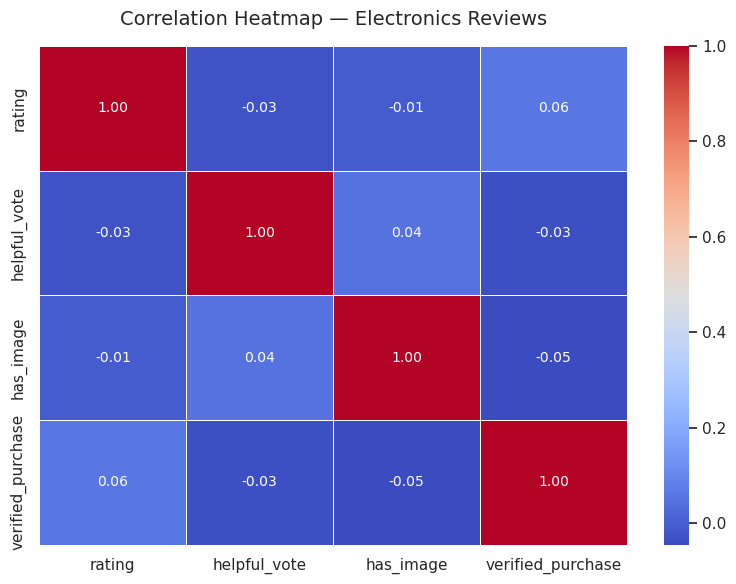

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":10}
)
plt.title("Correlation Heatmap — Electronics Reviews", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [89]:
plt.savefig("electronics_rating_trend.png", dpi=300)

<Figure size 640x480 with 0 Axes>